In [1]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import tenseal as ts
import matplotlib.pyplot as plt

os.makedirs(
    "../Outputs/Notebook_12",
    exist_ok=True
)

print(
    "Libraries Loaded Successfully"
)

Libraries Loaded Successfully


# Load Encryption Context

In [2]:
with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

context = ts.context_from(
    context_bytes
)

print(
    "Context Loaded"
)

Context Loaded


# Load Encrypted Templates

In [3]:
with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(
    "Encrypted Templates Loaded"
)

print(
    len(encrypted_embeddings)
)

Encrypted Templates Loaded
14446


# Convert Ciphertexts into CKKS Vectors

In [4]:
encrypted_vectors = []

for enc in encrypted_embeddings:

    encrypted_vectors.append(

        ts.ckks_vector_from(
            context,
            enc
        )

    )

print(
    "Encrypted Vectors Loaded"
)

print(
    len(encrypted_vectors)
)

Encrypted Vectors Loaded
14446


# Encrypted Cosine Similarity Function

In [5]:
def encrypted_similarity(
    enc_vec1,
    enc_vec2
):

    result = enc_vec1.dot(
        enc_vec2
    )

    return result.decrypt()[0]

# Load Image Labels

In [6]:
embeddings_df = pd.read_csv(
    "../Outputs/Notebook_05/compressed_embeddings_with_image.csv"
)

image_names = embeddings_df[
    "Image"
].tolist()

print(
    len(image_names)
)

14446


# Generate Genuine Pairs

In [10]:
subject_groups = {}

for idx, img in enumerate(image_names):

    subject = img[:5]

    if subject not in subject_groups:

        subject_groups[subject] = []

    subject_groups[subject].append(idx)

print(
    "Total Subjects:",
    len(subject_groups)
)

Total Subjects: 1000


In [11]:
print(
    subject_groups["S5000"][:10]
)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [13]:
subject_groups = {}

for idx, img in enumerate(image_names):

    subject = img[:5]

    if subject not in subject_groups:

        subject_groups[subject] = []

    subject_groups[subject].append(idx)

print(
    "Total Subjects:",
    len(subject_groups)
)

genuine_pairs = []

for subject in subject_groups:

    imgs = subject_groups[subject]

    if len(imgs) >= 2:

        for _ in range(

            min(
                len(imgs) // 2,
                5
            )

        ):

            idx1, idx2 = random.sample(
                imgs,
                2
            )

            genuine_pairs.append(
                (idx1, idx2)
            )

genuine_pairs = genuine_pairs[:1000]

print(
    "Genuine Pairs:",
    len(genuine_pairs)
)

Total Subjects: 1000
Genuine Pairs: 1000


# Generate Impostor Pairs

In [14]:
subjects = list(
    subject_groups.keys()
)

impostor_pairs = []

while len(impostor_pairs) < 1000:

    s1, s2 = random.sample(
        subjects,
        2
    )

    idx1 = random.choice(
        subject_groups[s1]
    )

    idx2 = random.choice(
        subject_groups[s2]
    )

    impostor_pairs.append(
        (idx1, idx2)
    )

print(
    "Impostor Pairs:",
    len(impostor_pairs)
)

Impostor Pairs: 1000


In [15]:
print(
    "Genuine Pairs:",
    len(genuine_pairs)
)

print(
    "Impostor Pairs:",
    len(impostor_pairs)
)

Genuine Pairs: 1000
Impostor Pairs: 1000


# Compute Genuine Matching Scores

In [16]:
genuine_scores = []

for idx1, idx2 in genuine_pairs:

    score = encrypted_similarity(

        encrypted_vectors[idx1],
        encrypted_vectors[idx2]

    )

    genuine_scores.append(
        score
    )

print(
    np.mean(genuine_scores)
)

0.18587135928494394


# Compute Impostor Matching Scores

In [17]:
impostor_scores = []

for idx1, idx2 in impostor_pairs:

    score = encrypted_similarity(

        encrypted_vectors[idx1],
        encrypted_vectors[idx2]

    )

    impostor_scores.append(
        score
    )

print(
    np.mean(impostor_scores)
)

-0.016235461662933954


# Similarity Score Distribution

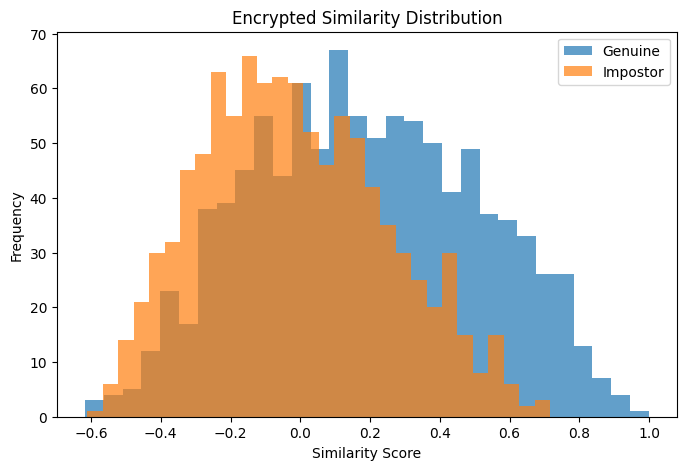

In [18]:
plt.figure(
    figsize=(8,5)
)

plt.hist(

    genuine_scores,

    bins=30,

    alpha=0.7,

    label="Genuine"

)

plt.hist(

    impostor_scores,

    bins=30,

    alpha=0.7,

    label="Impostor"

)

plt.xlabel(
    "Similarity Score"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Encrypted Similarity Distribution"
)

plt.legend()

plt.savefig(

    "../Outputs/Notebook_12/similarity_distribution.png"

)

plt.show()

# Matching Consistency Analysis

In [19]:
consistency_df = pd.DataFrame({

    "Metric": [

        "Average Genuine Score",
        "Average Impostor Score",
        "Genuine Score Std",
        "Impostor Score Std"

    ],

    "Value": [

        np.mean(genuine_scores),
        np.mean(impostor_scores),
        np.std(genuine_scores),
        np.std(impostor_scores)

    ]

})

consistency_df

,Metric,Value
0,Average Genuine Score,0.185871
1,Average Impostor Score,-0.016235
2,Genuine Score Std,0.326101
3,Impostor Score Std,0.265055


In [20]:
consistency_df.to_csv(

    "../Outputs/Notebook_12/matching_consistency.csv",

    index=False

)

print(
    "Matching Consistency Saved"
)

Matching Consistency Saved
